<a href="https://colab.research.google.com/github/2403a52264-debug/AIAC/blob/main/ML_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI prediction for job loss

# Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Step 2: Load Dataset

In [ ]:
df = pd.read_csv('/content/layoffs.csv')

# Preview data
df.head()

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
0,Digg,New York City,NaN,3/13/2026,NaN,Consumer,https://techcrunch.com/2026/03/13/digg-lays-of...,Acquired,49.0,United States,3/13/2026
1,Atlassian,"Sydney, Non-U.S.",1600.0,3/11/2026,0.1,Other,https://au.finance.yahoo.com/news/atlassian-la...,Post-IPO,210.0,Australia,3/11/2026
2,Flipkart,"Bengaluru, Non-U.S.",500.0,3/6/2026,NaN,Retail,https://inc42.com/buzz/flipkart-lays-off-about...,Acquired,12900.0,India,3/7/2026
3,SSense,"Montreal, Non-U.S.",215.0,3/5/2026,NaN,Retail,https://betakit.com/ssense-cut-more-than-200-j...,Series A,NaN,Canada,3/7/2026
4,Supernal,Los Angeles,296.0,3/4/2026,0.8,Transportation,https://www.latimes.com/business/story/2026-03...,Unknown,NaN,United States,3/7/2026


# Step 3: Data Cleaning

In [ ]:
# Convert date column
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Extract year and month
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Fill missing values
df['total_laid_off'] = df['total_laid_off'].fillna(0)
df['funds_raised'] = df['funds_raised'].fillna(df['funds_raised'].median())

# Create target variable (1 = layoff occurred)
df['layoff_event'] = df['total_laid_off'].apply(lambda x: 1 if x > 0 else 0)

df.head()

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added,year,month,layoff_event
0,Digg,New York City,0.0,2026-03-13,NaN,Consumer,https://techcrunch.com/2026/03/13/digg-lays-of...,Acquired,49.0,United States,3/13/2026,2026,3,0
1,Atlassian,"Sydney, Non-U.S.",1600.0,2026-03-11,0.1,Other,https://au.finance.yahoo.com/news/atlassian-la...,Post-IPO,210.0,Australia,3/11/2026,2026,3,1
2,Flipkart,"Bengaluru, Non-U.S.",500.0,2026-03-06,NaN,Retail,https://inc42.com/buzz/flipkart-lays-off-about...,Acquired,12900.0,India,3/7/2026,2026,3,1
3,SSense,"Montreal, Non-U.S.",215.0,2026-03-05,NaN,Retail,https://betakit.com/ssense-cut-more-than-200-j...,Series A,173.0,Canada,3/7/2026,2026,3,1
4,Supernal,Los Angeles,296.0,2026-03-04,0.8,Transportation,https://www.latimes.com/business/story/2026-03...,Unknown,173.0,United States,3/7/2026,2026,3,1


# Step 4: Exploratory Data Analysis

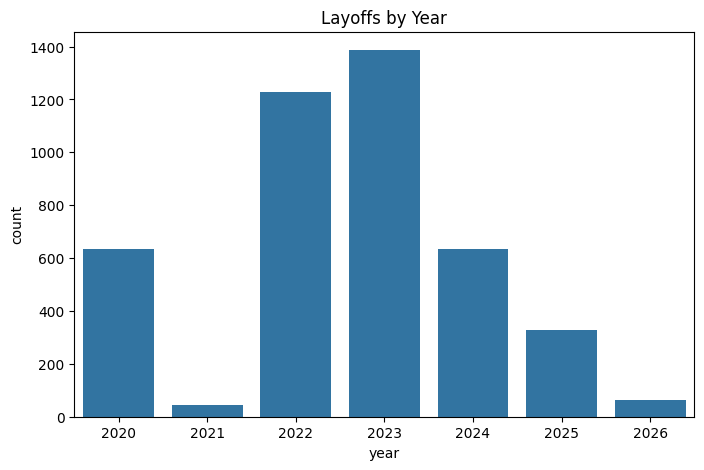

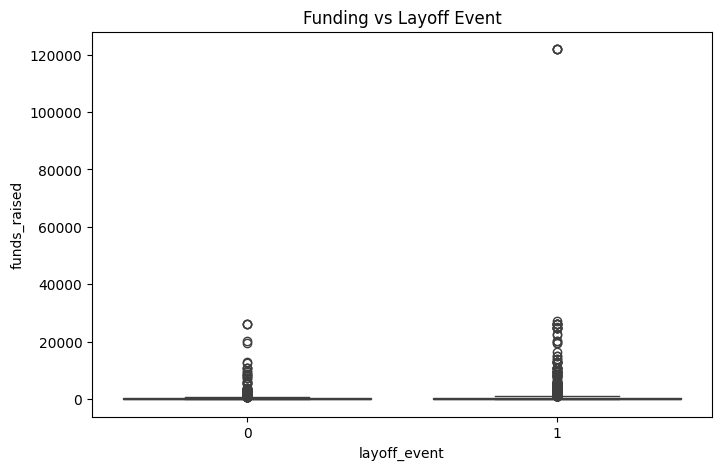

In [ ]:
# Layoffs by year
plt.figure(figsize=(8,5))
sns.countplot(x='year', data=df)
plt.title("Layoffs by Year")
plt.show()

# Funding vs layoffs
plt.figure(figsize=(8,5))
sns.boxplot(x='layoff_event', y='funds_raised', data=df)
plt.title("Funding vs Layoff Event")
plt.show()

# Step 5: Feature Engineering

In [ ]:
# Select important columns, removing 'company_size' as it's not present
df_model = df[['year', 'month', 'funds_raised', 'industry', 'layoff_event']]

# Convert categorical → numeric
df_model = pd.get_dummies(df_model, columns=['industry'], drop_first=True)

df_model.head()

,year,month,funds_raised,layoff_event,industry_Aerospace,industry_Construction,industry_Consumer,industry_Crypto,industry_Data,industry_Education,...,industry_Other,industry_Product,industry_Real Estate,industry_Recruiting,industry_Retail,industry_Sales,industry_Security,industry_Support,industry_Transportation,industry_Travel
0,2026,3,49.0,0,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2026,3,210.0,1,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,2026,3,12900.0,1,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,2026,3,173.0,1,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,2026,3,173.0,1,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


# Step 6: Train-Test Split

In [ ]:
# Separate features (X) and target (y)
X = df_model.drop('layoff_event', axis=1)
y = df_model['layoff_event']

# Perform train-test split (80/20 ratio, stratified for target variable)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Verify stratification
print("\ny_train value counts:\n", y_train.value_counts(normalize=True))
print("\ny_test value counts:\n", y_test.value_counts(normalize=True))

X_train shape: (3455, 32)
X_test shape: (864, 32)
y_train shape: (3455,)
y_test shape: (864,)

y_train value counts:
 layoff_event
1    0.655572
0    0.344428
Name: proportion, dtype: float64

y_test value counts:
 layoff_event
1    0.655093
0    0.344907
Name: proportion, dtype: float64


# Step 7: Train Model

In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

# Step 8: Model Evaluation

Accuracy: 0.5775462962962963

Classification Report:
               precision    recall  f1-score   support

           0       0.35      0.26      0.30       298
           1       0.66      0.74      0.70       566

    accuracy                           0.58       864
   macro avg       0.50      0.50      0.50       864
weighted avg       0.55      0.58      0.56       864



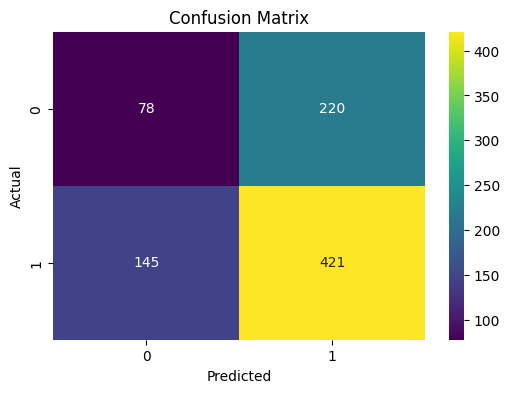

In [ ]:
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis') # Changed cmap to 'viridis'
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 9: Feature Importance

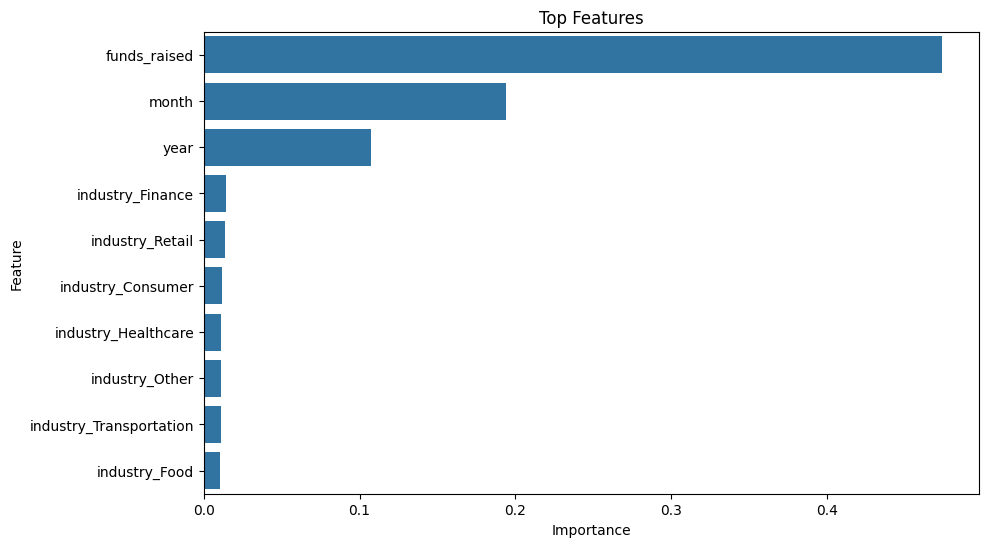

In [ ]:
importances = model.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_df.head(10))
plt.title("Top Features")
plt.show()

# Step 10: Prediction Function (Business Use)

In [ ]:
def predict_layoff(year, month, funding, industry, model, columns):
    # Create empty dataframe
    input_df = pd.DataFrame(columns=columns)

    # Fill basic values
    input_df.loc[0] = 0
    input_df['year'] = year
    input_df['month'] = month
    input_df['funds_raised'] = funding

    # Handle industry one-hot encoding
    col_name = 'industry_' + industry
    if col_name in input_df.columns:
        input_df[col_name] = 1

    # Prediction
    prob = model.predict_proba(input_df)[0][1]

    print(f"Layoff Risk: {round(prob*100,2)}%")
    return prob

# Step 11: Example Prediction

In [ ]:
predict_layoff(
    year=2026,
    month=3,
    funding=500,      # in millions
    industry='Technology',
    model=model,
    columns=X.columns
)

Layoff Risk: 86.0%


np.float64(0.86)

# 1. Add ROC-AUC Score

In [ ]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

ROC-AUC Score: 0.5253871510897147


# Try One More Model (Very Important)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.65625


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
import pickle

# save model
pickle.dump(model, open('model.pkl', 'wb'))